# Ejercicio 8 — Evolución 2024 · 2025 · 2026

Consultas de `sql/08_evolucion.sql` e indicadores de `sql/07_indicadores.sql`, ejecutadas sobre la base materializada `data/processed/taxi.duckdb` (121 M filas, reconstruida con `scripts/build_database.py`).
Interpretación en `docs/08_tres_anios.md`.

In [1]:
import sys
sys.path.insert(0, "../scripts")
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
from sqlrun import conectar, cargar_consultas

con = conectar("data/processed/taxi.duckdb", read_only=True)   # tablas materializadas
q = {**cargar_consultas("sql/07_indicadores.sql"), **cargar_consultas("sql/08_evolucion.sql")}
run = lambda n: con.sql(q[n].sql).df()
FIG = Path("docs/figuras"); FIG.mkdir(parents=True, exist_ok=True)
COLOR = {"yellow": "#d4a017", "green": "#2e8b57"}

## Resumen anual comparable (enero–agosto)

In [2]:
run("E1_resumen_anual")

,anio,taxi_type,viajes_por_dia,ingreso_diario_musd,ticket_mediano,distancia_mediana,tarifa_por_milla,pct_tarjeta,pct_sin_dato_pago,pct_paga_cbd,propina_pct_mediana
0,2024,yellow,104511.0,2.960,21.00,1.80,7.14,75.9,9.0,0.0,25.9
1,2025,yellow,119263.0,3.376,21.57,1.87,7.04,68.9,19.4,73.0,26.7
2,2026,yellow,117681.0,3.553,23.58,1.92,7.38,65.6,24.6,72.4,26.4
3,2024,green,1709.0,0.041,19.15,1.96,6.72,70.6,4.0,0.0,23.5
4,2025,green,1545.0,0.038,19.70,2.02,6.69,74.7,6.9,9.7,23.4
5,2026,green,1330.0,0.034,20.52,2.14,6.62,76.9,14.8,8.5,23.5


## Demanda: viajes por día y variación interanual

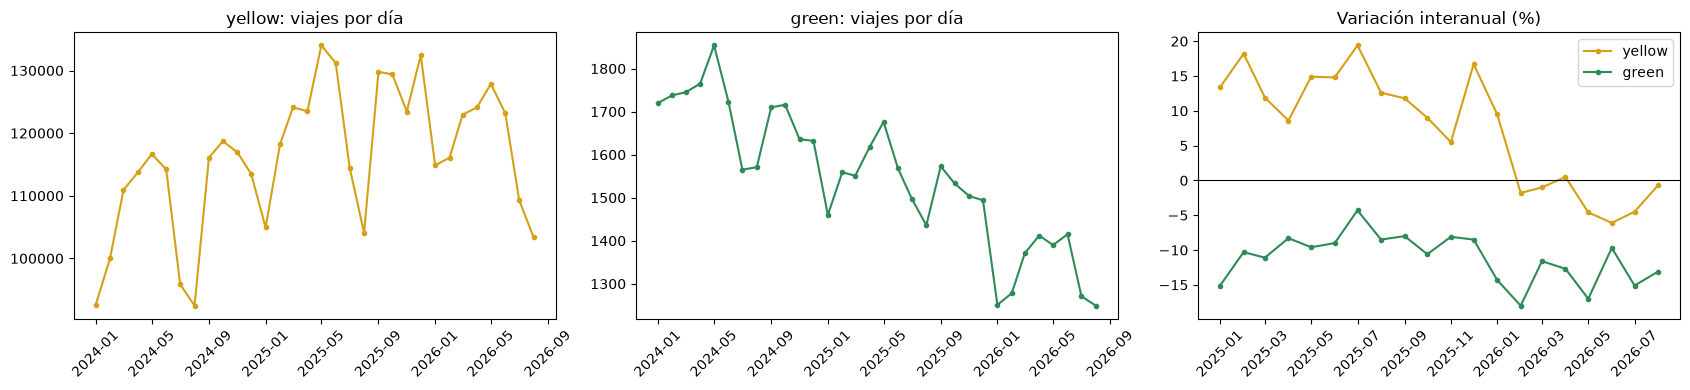

In [3]:
d = run("I1_viajes_diarios_por_mes"); v = run("E2_variacion_interanual")
fig, axes = plt.subplots(1, 3, figsize=(17, 4))
for taxi in ("yellow", "green"):
    s = d[d.taxi_type == taxi]
    axes[0 if taxi == "yellow" else 1].plot(s.mes, s.viajes_por_dia, marker="o", ms=3, color=COLOR[taxi])
    axes[0 if taxi == "yellow" else 1].set_title(f"{taxi}: viajes por día")
    s = v[v.taxi_type == taxi]
    axes[2].plot(s.mes, s.variacion_pct, marker="o", ms=3, color=COLOR[taxi], label=taxi)
axes[2].axhline(0, color="black", lw=.8); axes[2].set_title("Variación interanual (%)"); axes[2].legend()
for ax in axes: ax.tick_params(axis="x", rotation=45)
plt.tight_layout(); fig.savefig(FIG / "08_demanda.png", dpi=110, bbox_inches="tight")

## Precio, recargos y calidad de los datos de pago

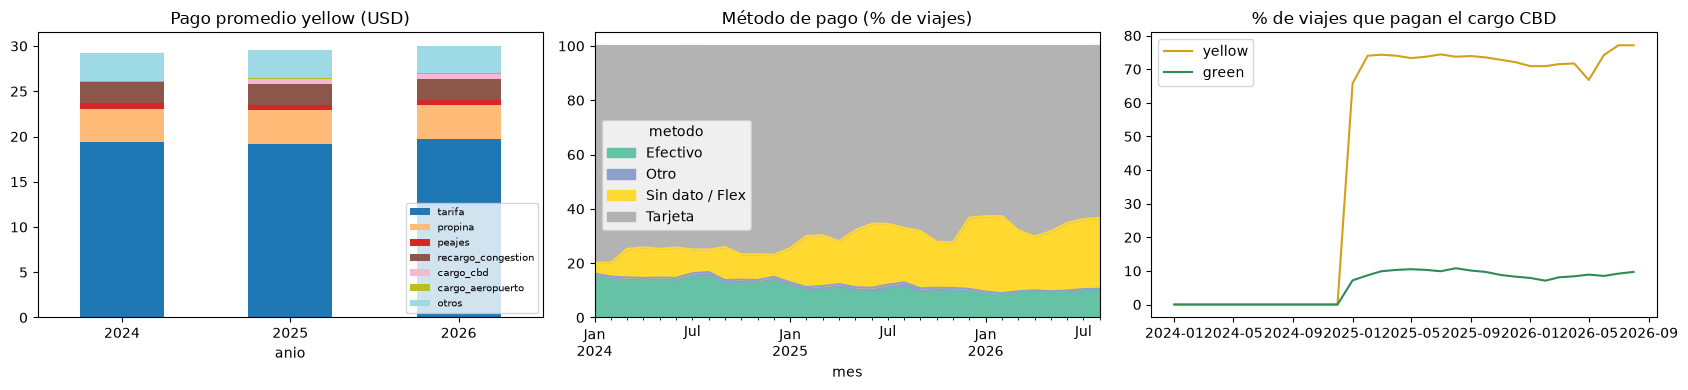

In [4]:
c = run("E6_composicion_del_ticket").set_index("anio")
p = run("I4_metodo_pago").pivot(index="mes", columns="metodo", values="pct")
cbd = run("I10_cargo_cbd")
fig, axes = plt.subplots(1, 3, figsize=(17, 4))
c.drop(columns="total_registrado").plot.bar(stacked=True, ax=axes[0], rot=0, colormap="tab20")
axes[0].set_title("Pago promedio yellow (USD)"); axes[0].legend(fontsize=7, loc="lower right")
p.plot.area(ax=axes[1], colormap="Set2"); axes[1].set_title("Método de pago (% de viajes)")
for taxi in ("yellow", "green"):
    s = cbd[cbd.taxi_type == taxi]
    axes[2].plot(s.mes, s.pct_paga_cbd, color=COLOR[taxi], label=taxi)
axes[2].set_title("% de viajes que pagan el cargo CBD"); axes[2].legend()
plt.tight_layout(); fig.savefig(FIG / "08_precio_y_pago.png", dpi=110, bbox_inches="tight")

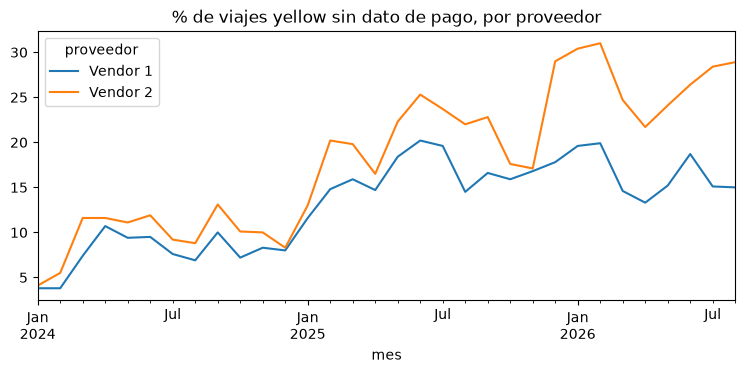

In [5]:
e7 = run("E7_sin_dato_por_proveedor").pivot(index="mes", columns="proveedor", values="pct_sin_dato")
ax = e7.plot(figsize=(9, 3.5), title="% de viajes yellow sin dato de pago, por proveedor")
ax.figure.savefig(FIG / "08_sin_dato_pago.png", dpi=110, bbox_inches="tight")

## Velocidad antes y después del peaje de congestión

,anio,grupo,velocidad_mediana_mph,viajes
0,2024,Manhattan (sin peaje aun),7.77,10304678
1,2025,No paga cargo CBD,8.49,2699258
2,2025,Paga cargo CBD,7.51,8157326
3,2026,No paga cargo CBD,8.14,2716032
4,2026,Paga cargo CBD,7.06,7738384


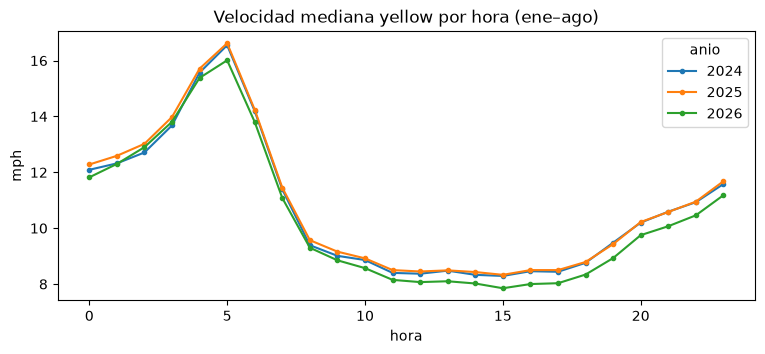

In [6]:
e4 = run("E4_velocidad_por_anio").pivot(index="hora", columns="anio", values="velocidad_mediana_mph")
ax = e4.plot(figsize=(9, 3.5), marker="o", ms=3, title="Velocidad mediana yellow por hora (ene–ago)")
ax.set_ylabel("mph"); ax.figure.savefig(FIG / "08_velocidad.png", dpi=110, bbox_inches="tight")
run("E5_velocidad_cbd")

## Cuota green y aeropuertos

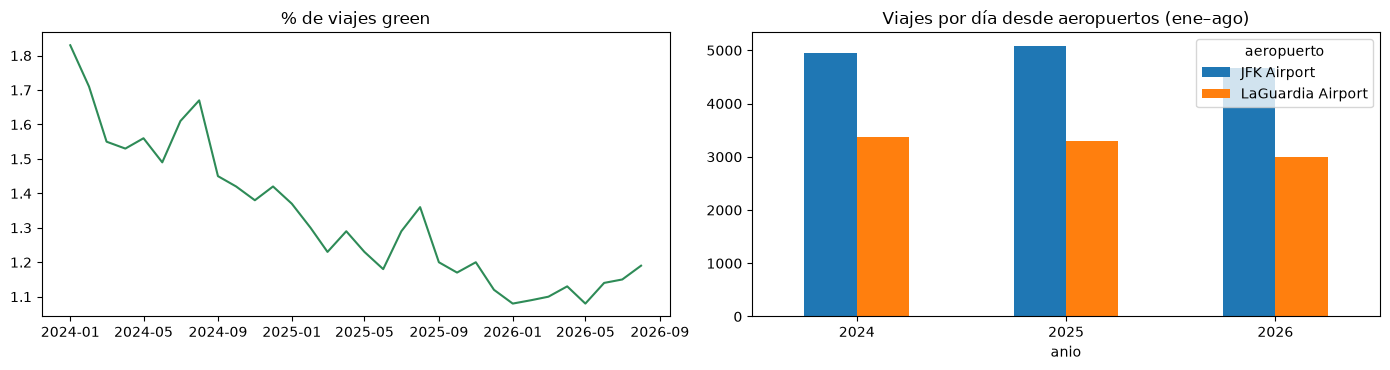

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 3.8))
e3 = run("E3_cuota_green"); axes[0].plot(e3.mes, e3.pct_green, color=COLOR["green"]); axes[0].set_title("% de viajes green")
e8 = run("E8_aeropuertos_por_anio").pivot(index="anio", columns="aeropuerto", values="viajes_por_dia")
e8.plot.bar(ax=axes[1], rot=0, title="Viajes por día desde aeropuertos (ene–ago)")
plt.tight_layout(); fig.savefig(FIG / "08_cuota_aeropuertos.png", dpi=110, bbox_inches="tight")